# Ejemplo de Inversión tomando los datos del terremoto de Copiapó del 6 de Junio de 2025

In [46]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'kdellipspy').exists():
            return p
    raise FileNotFoundError('No se encontro PROJECT_ROOT con carpeta kdellipspy.')
root = find_project_root(Path(os.getcwd()))
sys.path.append(str(root))

import kdellipspy as kde

In [48]:
input_ctl = root / 'inversions' / 'copiapo-06-06-2025' / 'input.ctl'
cfg = kde.ConfigParser(filepath = input_ctl)
# Ver qué tiene la clase en sí
help(cfg)

Help on ConfigParser in module kdellipspy.config_parser object:

class ConfigParser(builtins.object)
 |  ConfigParser(filepath: str)
 |  
 |  Parses and stores the inversion configuration from the 'input.ctl' file.
 |  (Parsea y almacena la configuración de la inversión desde el archivo 'input.ctl'.)
 |  
 |  This class is responsible for reading seismic event parameters, station grids, 
 |  filtering frequencies, and Neighbourhood Algorithm (NA) parameters, structuring 
 |  them for use throughout the pipeline.
 |  (Esta clase es responsable de leer los parámetros del evento sísmico, la grilla 
 |  de estaciones, las frecuencias de filtrado y los parámetros del algoritmo NA, 
 |  estructurándolos para su uso en el pipeline.)
 |  
 |  Attributes:
 |      filepath (str or Path): Path to the 'input.ctl' control file. 
 |                              (Ruta al archivo de control 'input.ctl'.)
 |      source_position (SourceConfig): Seismic source parameters. 
 |                            

In [49]:
str(input_ctl.parent / 'DATA')

'/home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/DATA'

In [50]:

print(f"Evento: {cfg.source_position.event_name}", flush=True)
print(f"Estaciones: {len(cfg.stations.stations)}", flush=True)
print(f"Frecuencia: {cfg.ellipse.freq1} - {cfg.ellipse.freq2} Hz", flush=True)

observed_waveforms, time_array = kde.load_and_filter_observed_data(
    freq1=cfg.ellipse.freq1,
    freq2=cfg.ellipse.freq2,
    input_ctl_path=str(input_ctl),
    data_dir=  str(input_ctl.parent / "DATA"),
    prefer_raw=False,
)

Evento: Event Copiapo 2025 INTRAPLATE
Estaciones: 10
Frecuencia: 0.02 - 0.1 Hz


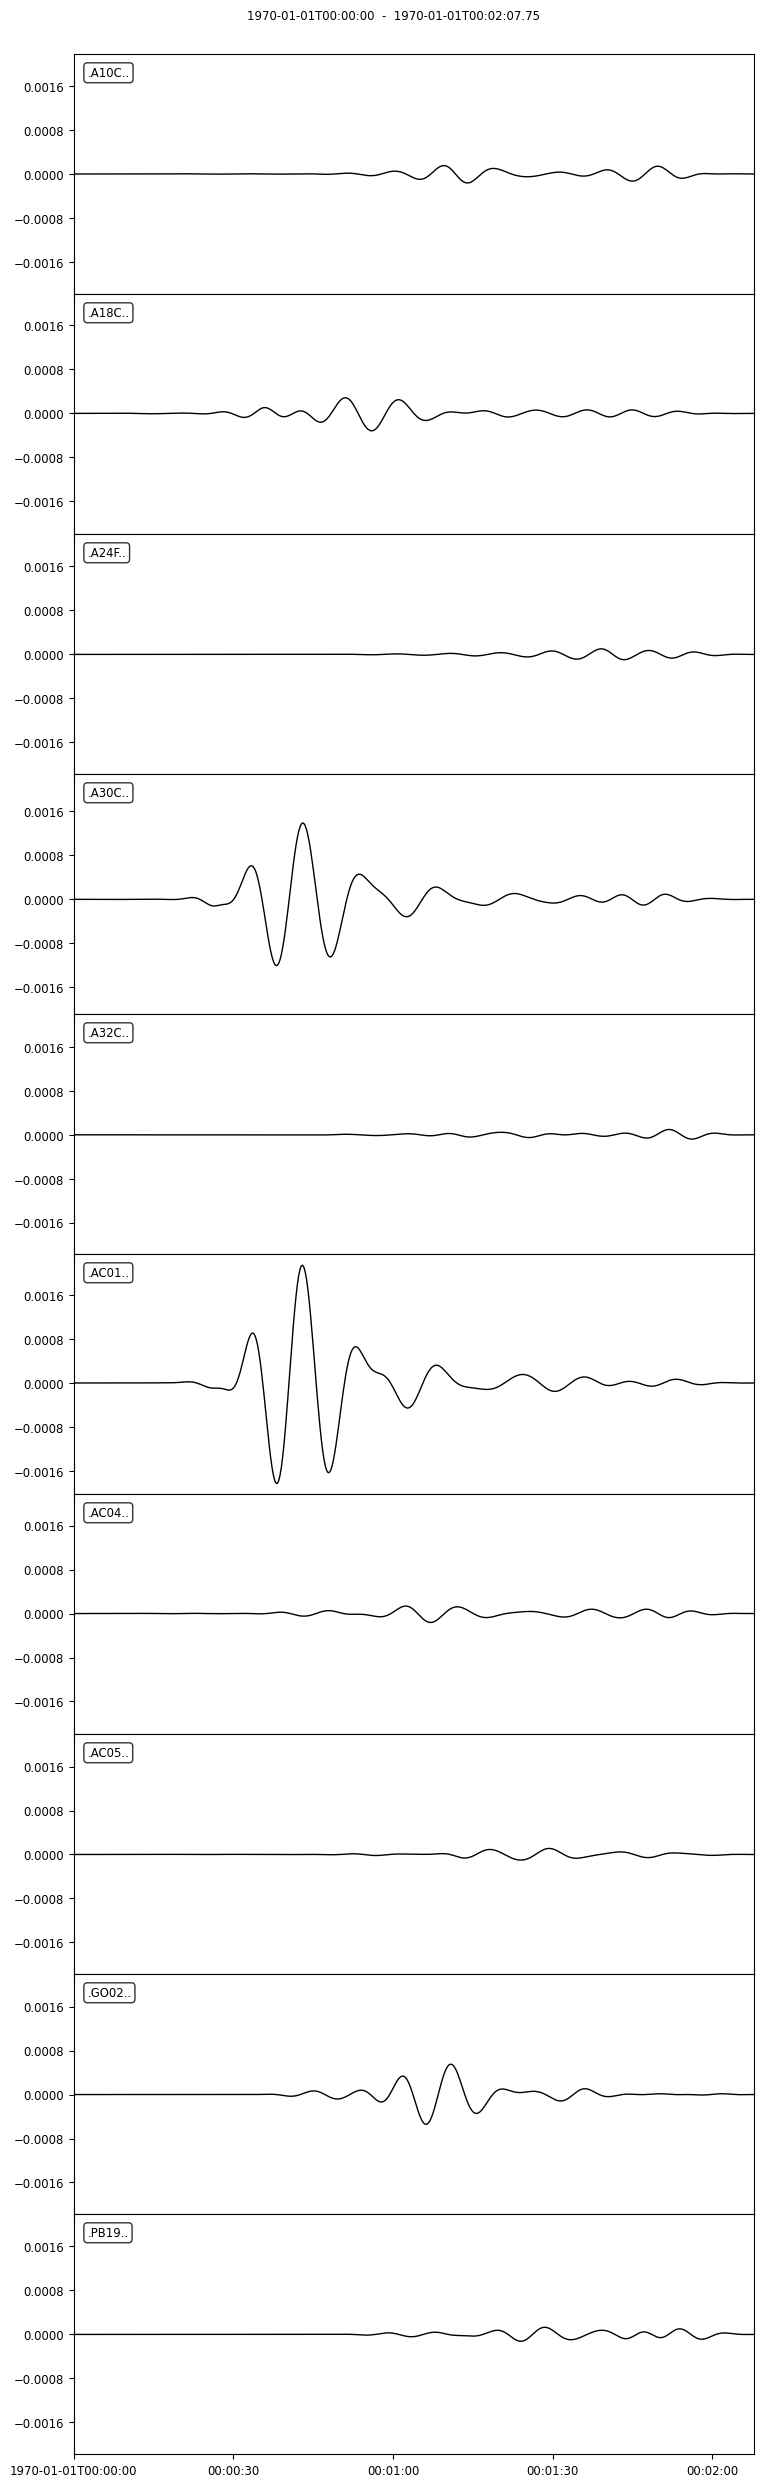

In [59]:
# make a stream and plot with obspy to check the data
try:
    import obspy
    st = obspy.Stream()
    for i, station in enumerate(cfg.stations.stations):
        tr = obspy.Trace(data=observed_waveforms[i,1])
        tr.stats.station = station.name
        tr.stats.starttime = 0
        tr.stats.delta = time_array[1] - time_array[0]
        st.append(tr)
    st.plot()
except ImportError:
    print("Obspy no está instalado, no se puede plotear la data. Instala obspy para visualizar las formas de onda.")

In [51]:
azi_times_array = None
try:
    azi_times_array = kde.build_azi_times_array(input_ctl_path=input_ctl)
    print(f"azi_times generado en memoria: shape={azi_times_array.shape}", flush=True)
except Exception as e:
    raise RuntimeError(
        "No se pudo generar azi_times en memoria. Instala obspy para calcular tiempos P/S."
    ) from e
print(f"Datos listos con forma: {observed_waveforms.shape}", flush=True)


azi_times generado en memoria: shape=(10, 3)
Datos listos con forma: (10, 3, 512)


In [52]:
axitra_dir = root / 'kdellipspy' / 'AXITRA2024'
inversion = kde.NAInversionModel(
    str(input_ctl),
    axitra_dir=str(axitra_dir),
    observed_waveforms=observed_waveforms,
    time_array=time_array,
    azi_times_array=azi_times_array,
)
help(inversion)

Help on NAInversionModel in module kdellipspy.inversion_na object:

class NAInversionModel(builtins.object)
 |  NAInversionModel(input_ctl_path: str, axitra_dir: Optional[str] = None, observed_waveforms: Optional[numpy.ndarray] = None, time_array: Optional[numpy.ndarray] = None, azi_times_array: Optional[numpy.ndarray] = None)
 |  
 |  Kinematic Inversion Model using the Neighbourhood Algorithm (NA).
 |  (Modelo de Inversión Cinemática utilizando el algoritmo Neighbourhood Algorithm.)
 |  
 |  Integrates observed data, arrival times, and event configuration to evaluate 
 |  different kinematic rupture models. It communicates with AXITRA to simulate 
 |  synthetic seismograms and calculate the misfit against real data.
 |  (Integra los datos observados, tiempos de llegada y configuración del evento 
 |  para evaluar distintos modelos de ruptura. Se comunica con AXITRA para simular 
 |  sismogramas sintéticos y calcular el error respecto a los datos reales.)
 |  
 |  Attributes:
 |      

In [53]:
na_config = kde.NAConfig(
        n_samples_initial=10,
        n_samples_iteration=10,
        n_iterations=0,
        n_cells_resample=10,
        random_seed=None,
    )

In [54]:
result = inversion.run_na_search(na_config)


[NA] Starting search: ni=10, ns=10, n=0, nr=10 -> expected evaluations=10
NAI - Initial Random Search
[NA] iter=000 eval=00001 misfit=6.001243e+02 best=6.001243e+02
[NA] iter=000 eval=00002 misfit=1.262636e+02 best=1.262636e+02
[NA] iter=000 eval=00003 misfit=5.225529e+02 best=1.262636e+02
[NA] iter=000 eval=00004 misfit=5.934565e+02 best=1.262636e+02
[NA] iter=000 eval=00005 misfit=8.475414e+01 best=8.475414e+01
[NA] iter=000 eval=00006 misfit=1.248173e+02 best=8.475414e+01
[NA] iter=000 eval=00007 misfit=7.350116e+02 best=8.475414e+01
[NA] iter=000 eval=00008 misfit=9.716375e+02 best=8.475414e+01
[NA] iter=000 eval=00009 misfit=1.374278e+02 best=8.475414e+01
[NA] iter=000 eval=00010 misfit=7.822939e+02 best=8.475414e+01


NAI - Optimisation Loop: 0it [00:00, ?it/s]
